In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MeanShift, estimate_bandwidth
from itertools import cycle
from sklearn.datasets import make_blobs

In [2]:
# Generate sample data

X, _ = make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=0.8,
    random_state=42
)

In [3]:
# Estimate bandwidth

bandwidth = estimate_bandwidth(
    X,
    quantile=0.2,
    n_samples=len(X)
)

print("Estimated bandwidth:", bandwidth)

Estimated bandwidth: 2.7812330088531754


In [4]:
meanshift_model = MeanShift(
    bandwidth=bandwidth,
    bin_seeding=True
)

In [5]:
meanshift_model.fit(X)

MeanShift(bandwidth=2.7812330088531754, bin_seeding=True)

In [6]:
cluster_centers = meanshift_model.cluster_centers_

print("Cluster centers:\n", cluster_centers)

Cluster centers:
 [[ 3.33256394  3.07837348]
 [-2.61855125  8.95290982]
 [-8.84492491  7.30505644]
 [-6.67836805 -6.9388912 ]]


In [7]:
labels = meanshift_model.labels_

num_clusters = len(np.unique(labels))

print("Number of clusters in input data =", num_clusters)

Number of clusters in input data = 4


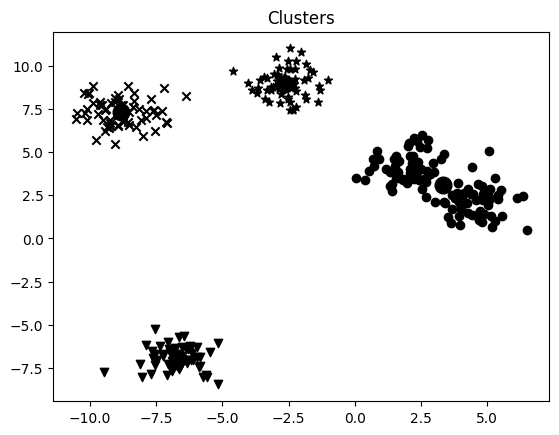

In [8]:
plt.figure()

markers = "o*xvs"

for i, marker in zip(range(num_clusters), markers):

    # Plot points belonging to cluster
    plt.scatter(
        X[labels == i, 0],
        X[labels == i, 1],
        marker=marker,
        color="black"
    )

    # Plot cluster center
    cluster_center = cluster_centers[i]

    plt.plot(
        cluster_center[0],
        cluster_center[1],
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=12
    )

plt.title("Clusters")

plt.show()